In [1]:
%pip install pandas openpyxl scipy scikit-learn catboost seaborn matplotlib statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

findex = pd.read_excel(
    r"C:\Users\georg\Downloads\GlobalFindexDatabase2025.xlsx",
    sheet_name="Data",
    skiprows=[1],
)

freedom = pd.read_excel(
    r"C:\Users\georg\Downloads\2026_indexofeconomicfreedom_data.xlsx",
    sheet_name="ef2026",
    header=1,
)

aggregates = {
    "WLD", "LMY", "EAP", "ECA", "MNA", "SSA",
    "LAC", "SAS", "HIC", "LIC", "LMC", "UMC",
}

metrics = ["g20.any", "merchant.pay", "fin26a"]

fin = findex.loc[
    (findex["year"] == 2024)
    & (findex["group"] == "all")
    & (findex["group2"] == "all")
    & (~findex["codewb"].isin(aggregates)),
    [
        "countrynewwb", "codewb", "regionwb24_hi",
        "incomegroupwb24", *metrics, "internet", "account.t.d",
    ],
].copy()

assert fin["codewb"].is_unique
assert freedom["Country"].is_unique

In [3]:
name_map = {
    "Congo, Dem. Rep.": "Democratic Republic of Congo",
    "Congo, Rep.": "Republic of Congo",
    "Czechia": "Czech Republic",
    "Egypt, Arab Rep.": "Egypt",
    "Gambia, The": "The Gambia",
    "Iran, Islamic Rep.": "Iran",
    "Korea, Rep.": "South Korea",
    "Lao PDR": "Laos",
    "Russian Federation": "Russia",
    "Slovak Republic": "Slovakia",
    "Taiwan, China": "Taiwan",
    "Turkiye": "Turkey",
    "Viet Nam": "Vietnam",
}

name_map.update({
    "Cote d'Ivoire": "Côte d’Ivoire",
    "Venezuela, RB": "Venezuela",
})

fin["freedom_country"] = fin["countrynewwb"].replace(name_map)

unmatched = fin.loc[
    ~fin["freedom_country"].isin(freedom["Country"]),
    ["countrynewwb", "codewb", "freedom_country"],
]
display(unmatched)  # проверь, дополни name_map и повтори объединение

data = fin.merge(
    freedom[["Country", "Overall Score"]],
    left_on="freedom_country",
    right_on="Country",
    how="inner",
    validate="one_to_one",
)

for col in [*metrics, "internet", "account.t.d", "Overall Score"]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.dropna(subset=["Overall Score", *metrics]).copy()
data["fintech_score"] = data[metrics].mean(axis=1) * 100

print("Countries in the final sample:", len(data))

,countrynewwb,codewb,freedom_country
623,"Hong Kong SAR, China",HKG,"Hong Kong SAR, China"
709,West Bank and Gaza,PSE,West Bank and Gaza


Countries in the final sample: 94


In [4]:
from scipy.stats import spearmanr

for target in ["fintech_score", *metrics]:
    subset = data[["Overall Score", target]].dropna()
    result = spearmanr(subset["Overall Score"], subset[target])
    print(
        f"{target:16s} n={len(subset):3d} "
        f"rho={result.statistic:+.3f}, p={result.pvalue:.3e}"
    )

fintech_score    n= 94 rho=+0.428, p=1.653e-05
g20.any          n= 94 rho=+0.364, p=3.138e-04
merchant.pay     n= 94 rho=+0.445, p=6.884e-06
fin26a           n= 94 rho=+0.405, p=5.047e-05


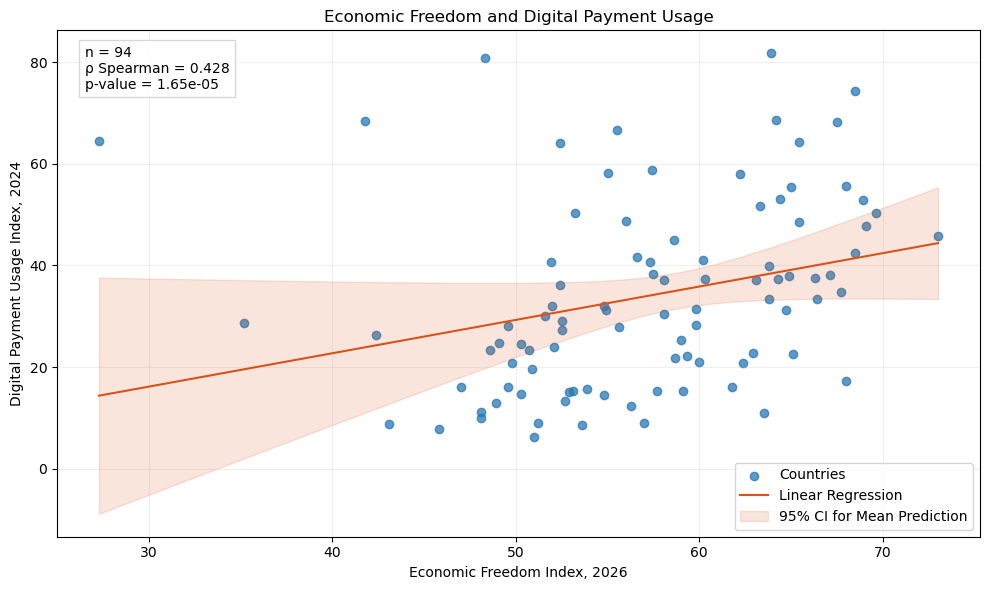

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import spearmanr

# Одинаковые страны для основного анализа и дополнительных моделей
analysis_data = (
    data.dropna(subset=[
        "fintech_score",
        "Overall Score",
        "regionwb24_hi",
        "incomegroupwb24",
    ])
    .rename(columns={
        "Overall Score": "freedom",
        "regionwb24_hi": "region",
        "incomegroupwb24": "income_group",
    })
    .reset_index(drop=True)
    .copy()
)

# Корреляция Спирмена
rho, p_corr = spearmanr(
    analysis_data["freedom"],
    analysis_data["fintech_score"],
)

# Основная регрессия без контролей
main_model = smf.ols(
    "fintech_score ~ freedom",
    data=analysis_data,
).fit(cov_type="HC3", use_t=True)

# Линия регрессии и доверительный интервал среднего значения
grid = pd.DataFrame({
    "freedom": np.linspace(
        analysis_data["freedom"].min(),
        analysis_data["freedom"].max(),
        200,
    )
})

prediction = main_model.get_prediction(grid).summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    analysis_data["freedom"],
    analysis_data["fintech_score"],
    alpha=0.75,
    color="#2878B5",
    label="Countries",
)

ax.plot(
    grid["freedom"],
    prediction["mean"],
    color="#D95319",
    label="Linear Regression",
)

ax.fill_between(
    grid["freedom"].to_numpy(),
    prediction["mean_ci_lower"].to_numpy(),
    prediction["mean_ci_upper"].to_numpy(),
    color="#D95319",
    alpha=0.15,
    label="95% CI for Mean Prediction",
)

ax.set_xlabel("Economic Freedom Index, 2026")
ax.set_ylabel("Digital Payment Usage Index, 2024")
ax.set_title("Economic Freedom and Digital Payment Usage")

ax.text(
    0.03, 0.97,
    f"n = {len(analysis_data)}\n"
    f"ρ Spearman = {rho:.3f}\n"
    f"p-value = {p_corr:.2e}",
    transform=ax.transAxes,
    va="top",
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="lightgray"),
)

ax.legend(loc="lower right")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score

# Подготовка единой выборки для обеих моделей
required = [
    "fintech_score",
    "Overall Score",
    "regionwb24_hi",
    "incomegroupwb24",
]

reg_data = (
    data.dropna(subset=required)
    .rename(columns={
        "Overall Score": "freedom",
        "regionwb24_hi": "region",
        "incomegroupwb24": "income_group",
    })
    .reset_index(drop=True)
    .copy()
)

cat_cols = ["region", "income_group"]
for col in cat_cols:
    reg_data[col] = reg_data[col].astype(str)

y = reg_data["fintech_score"]

print("Countries in regression analysis:", len(reg_data))


# Функция создаёт новую модель и обработку признаков
def make_linear_model(include_freedom):
    transformers = [
        (
            "categories",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False,
            ),
            cat_cols,
        )
    ]

    if include_freedom:
        transformers.append(
            ("numeric", "passthrough", ["freedom"])
        )

    return Pipeline([
        ("prepare", ColumnTransformer(transformers)),
        ("regression", LinearRegression()),
    ])


# Те же параметры разбиения, что и для CatBoost
cv = KFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []
oof_predictions = {
    "base": np.full(len(reg_data), np.nan),
    "full": np.full(len(reg_data), np.nan),
}

for fold, (train_idx, test_idx) in enumerate(
    cv.split(reg_data), start=1
):
    train = reg_data.iloc[train_idx]
    test = reg_data.iloc[test_idx]

    row = {"fold": fold}

    for name, include_freedom in [("base", False), ("full", True)]:
        model = make_linear_model(include_freedom)

        model.fit(train, y.iloc[train_idx])
        predictions = model.predict(test)

        oof_predictions[name][test_idx] = predictions
        row[name] = mean_absolute_error(
            y.iloc[test_idx], predictions
        )

    fold_results.append(row)

cv_scores = pd.DataFrame(fold_results).set_index("fold")
cv_scores["delta_MAE"] = cv_scores["full"] - cv_scores["base"]

display(cv_scores.round(3))

print(f"Average MAE without index: {cv_scores['base'].mean():.3f}")
print(f"Average MAE with index: {cv_scores['full'].mean():.3f}")
print(f"MAE Difference: {cv_scores['delta_MAE'].mean():+.3f}")

# Каждое предсказание сделано моделью, не обучавшейся на этой стране
for name in ["base", "full"]:
    print(
        f"OOF R² ({name}): "
        f"{r2_score(y, oof_predictions[name]):.3f}"
    )

Countries in regression analysis: 94


,base,full,delta_MAE
fold,,,
1,14.619,14.220,-0.399
2,14.199,14.656,0.456
3,9.749,8.896,-0.853
4,13.052,14.216,1.164
5,10.408,10.351,-0.057


Average MAE without index: 12.405
Average MAE with index: 12.468
MAE Difference: +0.062
OOF R² (base): 0.230
OOF R² (full): 0.219


In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# 1. Кодируем регион и группу дохода
controls = pd.get_dummies(
    reg_data[["region", "income_group"]],
    drop_first=True,
    dtype=float,
)

# 2. Начинаем с константы
X_controls = pd.DataFrame(
    {"const": 1.0},
    index=reg_data.index,
)

# Оставляем независимые контрольные столбцы.
# Это проверка структуры X, она не использует целевую переменную.
dropped = []

for col in controls.columns:
    candidate = pd.concat(
        [X_controls, controls[[col]]],
        axis=1,
    )

    if np.linalg.matrix_rank(candidate.to_numpy()) == candidate.shape[1]:
        X_controls = candidate
    else:
        dropped.append(col)

print("Redundant control columns:", dropped or "none")

# 3. Добавляем экономическую свободу
X = X_controls.copy()
X["freedom"] = reg_data["freedom"].astype(float)

if np.linalg.matrix_rank(X.to_numpy()) < X.shape[1]:
    raise ValueError(
        "Economic freedom is exactly expressed through the control "
        "variables. Its individual coefficient cannot be estimated."
    )

# 4. Оцениваем модель с робастными стандартными ошибками HC3
y = reg_data["fintech_score"].astype(float)

ols_model = sm.OLS(y, X)
ols_full = ols_model.fit(cov_type="HC3", use_t=True)

# 5. Таблица коэффициентов
ci = ols_full.conf_int(alpha=0.05)

coef_table = pd.DataFrame({
    "coefficient": ols_full.params,
    "std_error_HC3": ols_full.bse,
    "p_value": ols_full.pvalues,
    "CI_95_low": ci[0],
    "CI_95_high": ci[1],
})

display(coef_table)

# 6. Главный результат
beta = ols_full.params["freedom"]
p_value = ols_full.pvalues["freedom"]
ci_low, ci_high = ci.loc["freedom"]

print("\nRELATIONSHIP BETWEEN ECONOMIC FREEDOM AND FINTech")
print(f"Coefficient: {beta:+.3f}")
print(f"95% CI: [{ci_low:+.3f}; {ci_high:+.3f}]")
print(f"p-value: {p_value:.3e}")

print(
    "\nWhen regions and income groups are held constant, "
    "a 10-point difference in economic freedom corresponds to "
    f"an estimated difference in the fintech index of {10 * beta:+.2f} points."
)

print(
    "95% Confidence Interval for this difference: "
    f"[{10 * ci_low:+.2f}; {10 * ci_high:+.2f}]"
)

if p_value < 0.05:
    print("The relationship is statistically significant at the 5% level.")
else:
    print(
        "At the 5% level, there is insufficient evidence to reject "
        "the null hypothesis of no effect of economic freedom."
    )

print(f"\nR² on the training sample: {ols_full.rsquared:.3f}")
print(f"Adjusted R²: {ols_full.rsquared_adj:.3f}")
print(f"Number of observations: {int(ols_full.nobs)}")

Redundant control columns: ['income_group_Upper middle income']


,coefficient,std_error_HC3,p_value,CI_95_low,CI_95_high
const,90.861579,19.879477,1.656948e-05,51.329058,130.394100
region_Europe & Central Asia (excluding high income),-11.175406,8.301828,1.818797e-01,-27.684502,5.333691
region_High income,1.194760,10.128196,9.063780e-01,-18.946269,21.335789
region_Latin America & Caribbean (excluding high income),-21.910154,8.146050,8.625893e-03,-38.109468,-5.710840
region_Middle East & North Africa (excluding high income),-27.321827,11.375969,1.852423e-02,-49.944189,-4.699466
region_South Asia (excluding high income),-26.051457,9.272801,6.171805e-03,-44.491439,-7.611475
region_Sub-Saharan Africa (excluding high income),-12.675171,8.658895,1.469720e-01,-29.894332,4.543991
income_group_Low income,-30.250232,5.479458,3.684351e-07,-41.146736,-19.353728
income_group_Lower middle income,-17.896964,4.346928,8.929834e-05,-26.541306,-9.252622
freedom,-0.540583,0.290183,6.597072e-02,-1.117643,0.036477



RELATIONSHIP BETWEEN ECONOMIC FREEDOM AND FINTech
Coefficient: -0.541
95% CI: [-1.118; +0.036]
p-value: 6.597e-02

When regions and income groups are held constant, a 10-point difference in economic freedom corresponds to an estimated difference in the fintech index of -5.41 points.
95% Confidence Interval for this difference: [-11.18; +0.36]
At the 5% level, there is insufficient evidence to reject the null hypothesis of no effect of economic freedom.

R² on the training sample: 0.446
Adjusted R²: 0.387
Number of observations: 94


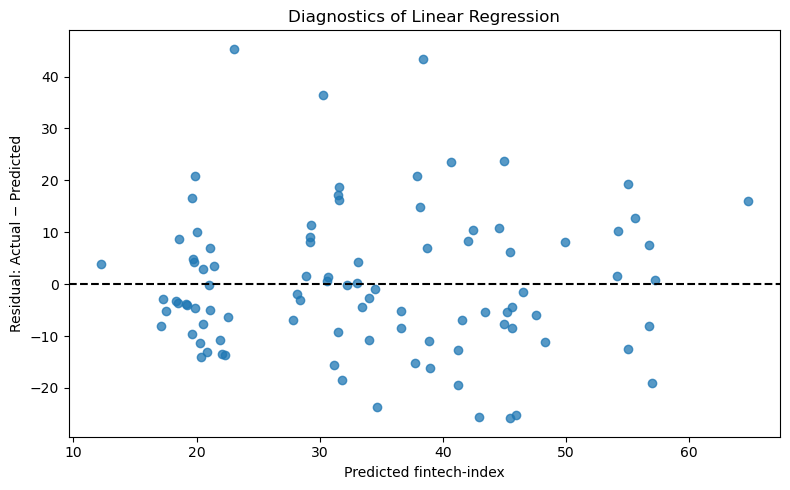

,countrynewwb,freedom,fintech_score,cooks_distance
40,"Iran, Islamic Rep.",41.8,68.405623,0.222501
58,Mongolia,63.9,81.757197,0.152590
46,Lao PDR,50.9,19.600392,0.058310
17,China,48.3,80.871788,0.047486
90,"Venezuela, RB",27.3,64.530692,0.046355
74,Poland,68.5,74.420283,0.043249
43,Kenya,55.5,66.682781,0.041688
70,Panama,64.9,37.971438,0.041514
14,Cambodia,58.7,21.749208,0.028081
0,Albania,68.0,17.252497,0.025625


In [8]:
import matplotlib.pyplot as plt

# Обычная OLS-подгонка даёт те же коэффициенты и остатки.
# Используем её для стандартной диагностики влияния.
ols_diagnostics = ols_model.fit()

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    ols_full.fittedvalues,
    ols_full.resid,
    alpha=0.75,
)
ax.axhline(0, color="black", linestyle="--")
ax.set_xlabel("Predicted fintech-index")
ax.set_ylabel("Residual: Actual − Predicted")
ax.set_title("Diagnostics of Linear Regression")

plt.tight_layout()
plt.show()

influence = ols_diagnostics.get_influence()

influence_table = reg_data[
    ["countrynewwb", "freedom", "fintech_score"]
].copy()

influence_table["cooks_distance"] = influence.cooks_distance[0]

display(
    influence_table
    .sort_values("cooks_distance", ascending=False)
    .head(10)
)

In [9]:
# Проверка чувствительности коэффициента freedom:
# каждый раз исключаем только одну страну

sensitivity_rows = []

for idx in reg_data.index:
    keep = reg_data.index != idx

    X_loo = X.loc[keep]
    y_loo = y.loc[keep]

    # Проверяем, можно ли оценить ту же модель без этой страны
    if np.linalg.matrix_rank(X_loo.to_numpy()) < X_loo.shape[1]:
        sensitivity_rows.append({
            "excluded_country": reg_data.loc[idx, "countrynewwb"],
            "beta_freedom": np.nan,
            "status": "Linear dependence after exclusion",
        })
        continue

    fitted = sm.OLS(y_loo, X_loo).fit()

    sensitivity_rows.append({
        "excluded_country": reg_data.loc[idx, "countrynewwb"],
        "beta_freedom": fitted.params["freedom"],
        "status": "OK",
    })

sensitivity = pd.DataFrame(sensitivity_rows)

original_beta = ols_full.params["freedom"]
sensitivity["change_beta"] = (
    sensitivity["beta_freedom"] - original_beta
)

# Страны, исключение которых сильнее всего меняет коэффициент
sensitivity["abs_change"] = sensitivity["change_beta"].abs()

display(
    sensitivity.sort_values("abs_change", ascending=False)
    [["excluded_country", "beta_freedom", "change_beta", "status"]]
    .head(10)
)

valid = sensitivity["beta_freedom"].dropna()

print(f"Coefficient on all countries: {original_beta:+.3f}")
print(
    "Range when excluding one country: "
    f"[{valid.min():+.3f}; {valid.max():+.3f}]"
)
print(
    "Number of exclusions changing the sign of the coefficient:",
    int((np.sign(valid) != np.sign(original_beta)).sum())
)

,excluded_country,beta_freedom,change_beta,status
90,"Venezuela, RB",-0.387043,0.153540,OK
40,"Iran, Islamic Rep.",-0.423497,0.117086,OK
17,China,-0.438468,0.102115,OK
93,Zimbabwe,-0.627780,-0.087197,OK
58,Mongolia,-0.622591,-0.082008,OK
46,Lao PDR,-0.606681,-0.066098,OK
22,Costa Rica,-0.594327,-0.053744,OK
11,Brazil,-0.490313,0.050270,OK
39,Indonesia,-0.505590,0.034993,OK
0,Albania,-0.506232,0.034351,OK


Coefficient on all countries: -0.541
Range when excluding one country: [-0.628; -0.387]
Number of exclusions changing the sign of the coefficient: 0


In [10]:
ci = main_model.conf_int(alpha=0.05)

main_results = pd.DataFrame({
    "coefficient": main_model.params,
    "std_error_HC3": main_model.bse,
    "p_value": main_model.pvalues,
    "CI_95_low": ci[0],
    "CI_95_high": ci[1],
})

display(main_results)

beta = main_model.params["freedom"]
ci_low, ci_high = ci.loc["freedom"]
p_reg = main_model.pvalues["freedom"]

print("MAIN MODEL: fintech_score ~ freedom")
print(f"Number of countries: {int(main_model.nobs)}")
print(f"Coefficient of freedom: {beta:+.3f}")
print(f"95% CI: [{ci_low:+.3f}; {ci_high:+.3f}]")
print(f"p-value: {p_reg:.3e}")
print(f"R²: {main_model.rsquared:.3f}")

print(
    "\nA 10-point difference in economic freedom corresponds to "
    f"an estimated difference in the fintech index of {10 * beta:+.2f} points."
)
print(
    "95% Confidence Interval for this difference: "
    f"[{10 * ci_low:+.2f}; {10 * ci_high:+.2f}]"
)

,coefficient,std_error_HC3,p_value,CI_95_low,CI_95_high
Intercept,-3.561867,21.669779,0.869800,-46.599918,39.476185
freedom,0.657100,0.367623,0.077161,-0.073031,1.387232


MAIN MODEL: fintech_score ~ freedom
Number of countries: 94
Coefficient of freedom: +0.657
95% CI: [-0.073; +1.387]
p-value: 7.716e-02
R²: 0.082

A 10-point difference in economic freedom corresponds to an estimated difference in the fintech index of +6.57 points.
95% Confidence Interval for this difference: [-0.73; +13.87]


In [11]:
import statsmodels.api as sm

specifications = [
    ("1. Freedom — main", []),
    ("2. Freedom + income", ["income_group"]),
    ("3. Freedom + region", ["region"]),
    ("4. Freedom + income + region", ["region", "income_group"]),
]

comparison_rows = []

for name, controls in specifications:
    # Константа
    design = pd.DataFrame(
        {"const": 1.0},
        index=analysis_data.index,
    )

    # Контрольные признаки без точного линейного дублирования
    if controls:
        dummies = pd.get_dummies(
            analysis_data[controls],
            drop_first=True,
            dtype=float,
        )

        for col in dummies.columns:
            candidate = pd.concat([design, dummies[[col]]], axis=1)

            if np.linalg.matrix_rank(candidate.to_numpy()) == candidate.shape[1]:
                design = candidate

    # Главный исследуемый признак
    design["freedom"] = analysis_data["freedom"].astype(float)

    if np.linalg.matrix_rank(design.to_numpy()) < design.shape[1]:
        raise ValueError(f"Coefficient of freedom is not identified: {name}")

    fitted = sm.OLS(
        analysis_data["fintech_score"].astype(float),
        design,
    ).fit(cov_type="HC3", use_t=True)

    low, high = fitted.conf_int().loc["freedom"]

    comparison_rows.append({
        "model": name,
        "n": int(fitted.nobs),
        "beta_freedom": fitted.params["freedom"],
        "CI_95_low": low,
        "CI_95_high": high,
        "p_value": fitted.pvalues["freedom"],
        "R_squared": fitted.rsquared,
        "adjusted_R_squared": fitted.rsquared_adj,
    })

model_comparison = pd.DataFrame(comparison_rows).set_index("model")
display(model_comparison.round(4))

,n,beta_freedom,CI_95_low,CI_95_high,p_value,R_squared,adjusted_R_squared
model,,,,,,,
1. Freedom — main,94,0.6571,-0.0730,1.3872,0.0772,0.0819,0.0719
2. Freedom + income,94,-0.1575,-0.8629,0.5479,0.6584,0.3142,0.2833
3. Freedom + region,94,-0.0223,-0.8187,0.7740,0.9556,0.2809,0.2224
4. Freedom + income + region,94,-0.5406,-1.1176,0.0365,0.0660,0.4460,0.3867


На выборке 94 стран выявлена умеренная положительная ранговая связь экономической свободы с использованием цифровых платежей, при этом линейный коэффициент не является статистически значимым на уровне 5%, а положительная связь не сохраняется в рассмотренных моделях с контролями. Оснований утверждать причинное влияние экономической свободы нет.